# Segmentation et morphologie

## Description

La segmentation sert a isoler la voiture dans une ROI definie manuellement. Otsu calcule un seuil global dans la ROI, tandis que le seuillage adaptatif calcule un seuil local. La ROI limite l'influence du reste de la scene. L'ouverture morphologique supprime les petits bruits, la fermeture remplit les petits trous, et la plus grande composante connectee conserve la region principale de la voiture.


Frames chargees: 1661
Bbox manuelle utilisee dans les notebooks: (535, 300, 220, 105)


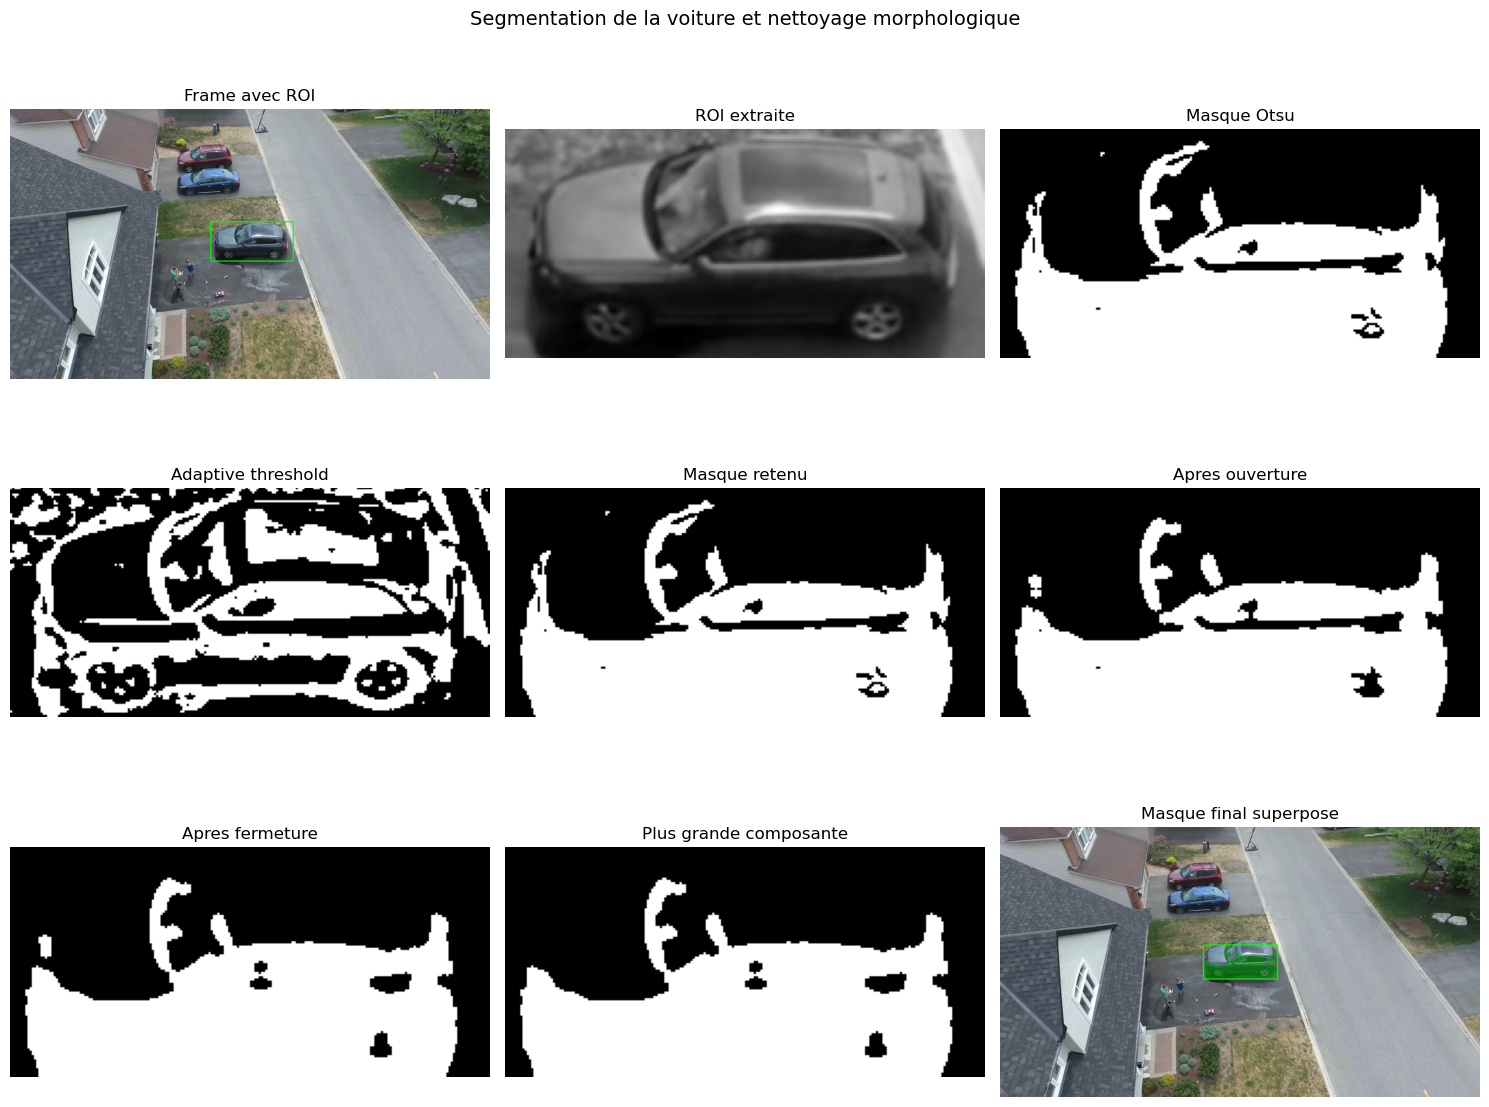

Grille sauvegardee: c:\Users\espacegamers\Desktop\Master IAII\Cours\drive-download-20251005T182208Z-1-001\S2\Traitement d_images et vision par ordinateur_\Projet\motion-estimation-project\results\segmentation\segmentation_morphology_grid.png
Bbox estimee depuis le masque: (542, 314, 198, 91)


In [2]:
from pathlib import Path
import sys

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATASET_DIR = PROJECT_ROOT / "data" / "car" / "car-11" / "img"
RESULTS_DIR = PROJECT_ROOT / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

image_files = sorted([p for p in DATASET_DIR.iterdir() if p.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}])
if not image_files:
    raise RuntimeError("Aucune image trouvee dans data/car/car-11/img/.")

initial_bbox = (535, 300, 220, 105)  # x, y, w, h

def ensure_dir(path):
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path

def bgr_to_rgb(image):
    return cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

def show_bgr(image, title, figsize=(12, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(bgr_to_rgb(image))
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_gray(image, title, figsize=(8, 5)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap="gray")
    plt.title(title)
    plt.axis("off")
    plt.show()

def show_saved_image(path, title=None, figsize=(12, 6), is_gray=False):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(path)
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE if is_gray else cv2.IMREAD_COLOR)
    if image is None:
        raise RuntimeError(f"Image illisible: {path}")
    if is_gray:
        show_gray(image, title or path.name, figsize=figsize)
    else:
        show_bgr(image, title or path.name, figsize=figsize)
    return image

def save_bgr(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def save_gray(path, image):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    cv2.imwrite(str(path), image)
    return path

def draw_bbox_local(image, bbox, color=(0, 255, 0), thickness=2):
    out = image.copy()
    x, y, w, h = [int(v) for v in bbox]
    cv2.rectangle(out, (x, y), (x + w, y + h), color, thickness)
    return out

def draw_points_local(image, points, color=(0, 0, 255)):
    out = image.copy()
    if points is None:
        return out
    for px, py in np.asarray(points).reshape(-1, 2):
        cv2.circle(out, (int(px), int(py)), 3, color, -1)
    return out

def draw_mask_overlay_local(frame, mask, bbox):
    out = frame.copy()
    overlay = out.copy()
    x, y, w, h = [int(v) for v in bbox]
    mask_roi = mask
    if mask_roi.shape[:2] != (h, w):
        mask_roi = cv2.resize(mask_roi, (w, h), interpolation=cv2.INTER_NEAREST)
    roi = overlay[y:y+h, x:x+w]
    roi[mask_roi > 0] = (0, 255, 0)
    overlay[y:y+h, x:x+w] = roi
    return cv2.addWeighted(overlay, 0.35, out, 0.65, 0)

print(f"Frames chargees: {len(image_files)}")
print(f"Bbox manuelle utilisee dans les notebooks: {initial_bbox}")

from src.preprocessing import preprocess_image_with_method
from src.detection import otsu_threshold, adaptive_threshold, open_mask, close_mask, largest_connected_component, bbox_from_mask

segmentation_dir = ensure_dir(RESULTS_DIR / "segmentation")
morphology_dir = ensure_dir(RESULTS_DIR / "morphology")
frame = cv2.imread(str(image_files[0]))
gray = preprocess_image_with_method(frame, method="stretching")["enhanced"]
x, y, w, h = initial_bbox
roi = gray[y:y+h, x:x+w]
frame_with_roi = draw_bbox_local(frame, initial_bbox)

otsu_mask = otsu_threshold(roi, invert=True)
adaptive_mask = adaptive_threshold(roi, invert=True)
selected_mask = otsu_mask
opened_mask = open_mask(selected_mask, kernel_size=(5, 5))
closed_mask = close_mask(opened_mask, kernel_size=(5, 5))
largest = largest_connected_component(closed_mask)
segmented_bbox = bbox_from_mask(largest, parent_bbox=initial_bbox)
overlay = draw_mask_overlay_local(frame, largest, initial_bbox)
if segmented_bbox is not None:
    overlay = draw_bbox_local(overlay, segmented_bbox)

save_bgr(segmentation_dir / "frame_with_manual_roi.png", frame_with_roi)
save_gray(segmentation_dir / "roi_gray.png", roi)
save_gray(segmentation_dir / "mask_otsu.png", otsu_mask)
save_gray(segmentation_dir / "mask_adaptive.png", adaptive_mask)
save_gray(segmentation_dir / "mask_selected.png", selected_mask)
save_gray(morphology_dir / "mask_after_opening.png", opened_mask)
save_gray(morphology_dir / "mask_after_closing.png", closed_mask)
save_gray(morphology_dir / "largest_connected_component.png", largest)
save_bgr(segmentation_dir / "final_mask_overlay.png", overlay)

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
items = [
    ("Frame avec ROI", frame_with_roi, False),
    ("ROI extraite", roi, True),
    ("Masque Otsu", otsu_mask, True),
    ("Adaptive threshold", adaptive_mask, True),
    ("Masque retenu", selected_mask, True),
    ("Apres ouverture", opened_mask, True),
    ("Apres fermeture", closed_mask, True),
    ("Plus grande composante", largest, True),
    ("Masque final superpose", overlay, False),
]
for ax, (title, image, gray_mode) in zip(axes.ravel(), items):
    ax.imshow(image if gray_mode else bgr_to_rgb(image), cmap="gray" if gray_mode else None)
    ax.set_title(title)
    ax.axis("off")
fig.suptitle("Segmentation de la voiture et nettoyage morphologique", fontsize=14)
fig.tight_layout()
comparison_path = segmentation_dir / "segmentation_morphology_grid.png"
fig.savefig(comparison_path, dpi=150)
plt.show()
print("Grille sauvegardee:", comparison_path)
print("Bbox estimee depuis le masque:", segmented_bbox)


## Interpretation

Otsu donne un masque global simple dans la ROI, tandis que le seuillage adaptatif peut faire apparaitre davantage de details locaux. Le masque Otsu est retenu ici car il reste plus compact pour la voiture. L'ouverture retire des petits pixels parasites, la fermeture rend la region plus continue, et la plus grande composante connectee conserve l'objet principal. Ce masque nettoye aide a selectionner des points Lucas-Kanade plus pertinents sur la voiture.


## Resume de l'etape

La voiture a ete isolee dans une ROI manuelle, puis le masque a ete nettoye par morphologie. Le resultat servira a stabiliser le suivi optique en concentrant les points sur l'objet et non sur l'arriere-plan.
